In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import inspeqtor.experimental as sq
import seaborn as sns
import numpyro.distributions as dist
from numpyro.infer import Predictive
from numpyro.util import enable_x64
import pandas as pd
import scienceplots as scienceplots
import pathlib
import gen_data as ml
from rich.progress import track

enable_x64(use_x64=True)

In [2]:
key = jax.random.key(0)

In [3]:
def prepare_PGM_predictive_fn(loaded_data: sq.utils.LoadedData, path):
    shots = loaded_data.experiment_data.experiment_config.shots

    characterized_result = sq.probabilistic.SVIResult.from_file(path / "model.json")

    base_model = sq.models.linen.WoModel(
        hidden_sizes_1=characterized_result.config["model_config"]["hidden_sizes"][0],
        hidden_sizes_2=characterized_result.config["model_config"]["hidden_sizes"][1],
    )

    graybox_model = sq.probabilistic.make_flax_probabilistic_graybox_model(
        name="graybox",
        base_model=base_model,
        adapter_fn=sq.probabilistic.observable_to_expvals,
        prior=dist.Normal(0, 1),
    )

    model = sq.probabilistic.make_probabilistic_model(
        predictive_model=graybox_model,
    )

    # initialize guide
    guide = sq.probabilistic.auto_diagonal_normal_guide(
        model,
        ml.feature_map(loaded_data.control_parameters),
        loaded_data.unitaries,
        jnp.zeros(shape=(shots, loaded_data.control_parameters.shape[0], 18)),
    )

    predictive_fn = Predictive(
        model=sq.probabilistic.make_probabilistic_model(
            predictive_model=graybox_model,
            log_expectation_values=True,
        ),
        guide=guide,
        params=characterized_result.params,
        num_samples=shots,
    )

    return predictive_fn

In [4]:
palette = {"PGM": "#6366f1", "SGM": "#f43f5e", "Device": "#f97316", "Noiseless": "gray"}

In [5]:
EXPERIMENT_ID = "0001"
data_path = pathlib.Path(f"./data/PSD/{EXPERIMENT_ID}")
# Ensure that path to dataset exists
assert data_path.exists()
# Read the noise setting first
config = sq.data.ExperimentConfiguration.from_file(data_path)
# Read the noise setting first
noise_config = config.additional_info
DETUNE = float(noise_config["DETUNE"])
NOISE_STR = float(noise_config["NOISE_STR"])
TROTTERIZATION = bool(noise_config["TROTTERIZATION"])
TROTTER_STEPS = int(noise_config["TROTTER_STEPS"])

# Setup model path
PGM_model_path = pathlib.Path(f"model/PSD/{EXPERIMENT_ID}/PGM")

# SGM model path
sgm_model_path = pathlib.Path(f"model/PSD/{EXPERIMENT_ID}/SGM")

assert PGM_model_path.exists() and sgm_model_path.exists()

data_model = ml.get_data_model(
    noise_str=NOISE_STR,
    detune=DETUNE,
    trotter_steps=TROTTER_STEPS,
)

In [6]:
loaded_data = sq.predefined.load_data_from_path(
    data_path,
    hamiltonian_spec=sq.predefined.HamiltonianSpec(
        method=sq.predefined.WhiteboxStrategy.TROTTER
        if TROTTERIZATION
        else sq.predefined.WhiteboxStrategy.ODE,
        trotter_steps=TROTTER_STEPS,
    ),
)

shots = loaded_data.experiment_data.experiment_config.shots

## Select the control parameters interval

In [7]:
df = loaded_data.experiment_data.postprocessed_data
subset_df = df[(df["parameter/0/theta"] > 1.3) & (df["parameter/0/theta"] < 1.7)]
subset_df[["parameters_id", "parameter/0/theta"]]

,parameters_id,parameter/0/theta
207,207,1.301921
208,208,1.308211
209,209,1.314500
210,210,1.320790
211,211,1.327079
...,...,...
266,266,1.673000
267,267,1.679290
268,268,1.685579
269,269,1.691869


In [8]:
NUM_REALIZATIONS = 1000
control_parameters = jnp.array(subset_df["parameter/0/theta"].to_numpy()).reshape(-1, 1)
control_parameters_indices = subset_df["parameters_id"]
unitaries = jax.vmap(loaded_data.whitebox)(control_parameters)[:, -1, :, :]

## Define the AGF function

In [9]:
sx_agf_fn = sq.physics.direct_AGF_estimation_fn(sq.constant.SX)

## Ideal distributions

In [10]:
# Use shot estimated of expectation value with real noise model solver

key, subkey = jax.random.split(key)

ideal_shots_noise = jax.vmap(
    sq.utils.shot_quantum_device, in_axes=(0, None, None, None)
)(
    jax.random.split(subkey, NUM_REALIZATIONS),
    control_parameters,
    loaded_data.whitebox,
    shots,
)

# Calculate AGF to SX gate
ideal_shots_noisy_agfs = jax.vmap(jax.vmap(sx_agf_fn))(ideal_shots_noise)

## True

In [11]:
key, subkey = jax.random.split(key)
_true_agfs = []
for parameters_id in track(control_parameters_indices):
    expvals_df = pd.read_csv(
        data_path / "interm_expvals" / f"parameters_{str(parameters_id).zfill(4)}.csv"
    )
    expvals = jnp.array(
        expvals_df[
            [
                f"{exp.initial_state}/{exp.observable}"
                for exp in sq.constant.default_expectation_values_order
            ]
        ].to_numpy()
    )

    _true_expvals = []
    for exp_idx, _ in enumerate(sq.constant.default_expectation_values_order):
        key, subkey = jax.random.split(key)
        probs = sq.utils.expectation_value_to_prob_plus(expvals[:, exp_idx])

        sim = jax.vmap(ml.simulate_the_shot, in_axes=(0, None))(
            jax.random.split(subkey, int(NUM_REALIZATIONS * shots)), probs
        )

        stochastic_expval_sample = sim.reshape(NUM_REALIZATIONS, shots).mean(1)
        _true_expvals.append(stochastic_expval_sample)
    true_expvals = jnp.array(_true_expvals).T

    true_agf_param = jax.vmap(sx_agf_fn)(true_expvals)
    _true_agfs.append(true_agf_param)

true_agfs = jnp.array(_true_agfs).T

Output()

## PGM

In [12]:
pgm_predictive_fn = prepare_PGM_predictive_fn(loaded_data, PGM_model_path)

In [13]:
key, subkey = jax.random.split(key)

res = jax.vmap(pgm_predictive_fn, in_axes=(0, None, None))(
    jax.random.split(subkey, NUM_REALIZATIONS),
    ml.feature_map(control_parameters),
    unitaries,
)

predictive_results = jnp.mean(sq.utils.binary_to_eigenvalue(res['obs']), axis=1)
pgm_agfs = jax.vmap(jax.vmap(sx_agf_fn))(predictive_results)

## SGM

In [14]:
sgm_model_state = sq.model.ModelData.from_file(sgm_model_path / "model.json")

sgm_predictive_model = sq.probabilistic.make_predictive_resampling_model(
    sq.models.linen.make_predictive_fn(
        sq.models.observable_to_expvals,
        sq.models.linen.WoModel(**sgm_model_state.config),
        sgm_model_state.params,
    ),
    shots=shots,
)

In [15]:
key, subkey = jax.random.split(key)

sgm_posterior_predictive_results = jax.vmap(
    sgm_predictive_model, in_axes=(0, None, None)
)(
    jax.random.split(subkey, NUM_REALIZATIONS),
    ml.feature_map(control_parameters),
    unitaries,
)

sgm_agfs = jax.vmap(jax.vmap(sx_agf_fn))(sgm_posterior_predictive_results)
sgm_agfs.shape

(1000, 64)

In [16]:
rows = []

for ctrl_idx, ctrl_param in enumerate(control_parameters):
    for traj_idx in range(NUM_REALIZATIONS):
        rows.append(
            {
                "AGF": ideal_shots_noisy_agfs[traj_idx, ctrl_idx].item(),
                "param_idx": ctrl_idx,
                "param": ctrl_param.item(),
                "backend": "Noiseless",
            }
        )

        rows.append(
            {
                "AGF": true_agfs[traj_idx, ctrl_idx].item(),
                "param_idx": ctrl_idx,
                "param": ctrl_param.item(),
                "backend": "Device",
            }
        )

        rows.append(
            {
                "AGF": pgm_agfs[traj_idx, ctrl_idx].item(),
                "param_idx": ctrl_idx,
                "param": ctrl_param.item(),
                "backend": "PGM",
            }
        )

        rows.append(
            {
                "AGF": sgm_agfs[traj_idx, ctrl_idx].item(),
                "param_idx": ctrl_idx,
                "param": ctrl_param.item(),
                "backend": "SGM",
            }
        )

agfs_df = pd.DataFrame(rows)

agfs_df.to_csv(data_path / "agfs_data.csv", index=False)

## Load result for visualization.

In [17]:
agfs_df = pd.read_csv(data_path / "agfs_data.csv")
# Calculate the absolute deviation from the median for each group
agfs_df["concentration"] = abs(
    agfs_df["AGF"]
    - agfs_df.groupby(["param_idx", "backend"])["AGF"].transform("median")
)

In [18]:
# 0001
optimized_results = {
    "SGM": jnp.array([1.3840064678519872]),
    "PGM": jnp.array([1.428678583310686]),
}

times = {
    "SGM": {
        "training": 18.34742283821106,
        "control": 174.7191219329834
    },
    "PGM": {
        "training": 362.8393180370331,
        "control": 569.9754960536957
    }
}

In [48]:
import matplotlib.ticker as ticker
import numpy as np
from fractions import Fraction


def format_x_axis_as_pi_specific(ax, custom_ticks=None):
    """
    Format x-axis with specific pi-based ticks

    Parameters:
    -----------
    ax : matplotlib axis object
    custom_ticks : list of float, optional
        Custom tick locations. If None, uses reasonable defaults for 1.3-1.7 range
    """

    if custom_ticks is None:
        # Default ticks for your range (1.3 to 1.7)
        custom_ticks = [1.3, 1.4, 1.5, 1.6, 1.7]

    def pi_formatter(x, pos):
        if abs(x) < 1e-10:
            return "0"

        coeff = x / np.pi

        # Try simple fractions first
        try:
            frac = Fraction(coeff).limit_denominator(20)
            if abs(coeff - float(frac)) < 1e-3:
                if frac.denominator == 1:
                    return rf"${frac.numerator} \pi $" if frac.numerator != 1 else r"$\pi$"
                else:
                    return (
                        rf"${frac.numerator} \pi /{frac.denominator}$"
                        if frac.numerator != 1
                        else rf"$\pi /{frac.denominator}$"
                    )
        except:
            pass

        # Use decimal with π
        return rf"${coeff:.2f} \pi$"

    ax.set_xticks(custom_ticks)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))

    return ax




# For reuse in other plots:
# format_x_axis_as_pi_specific(other_ax, custom_ticks=[1.2, 1.4, 1.6, 1.8])


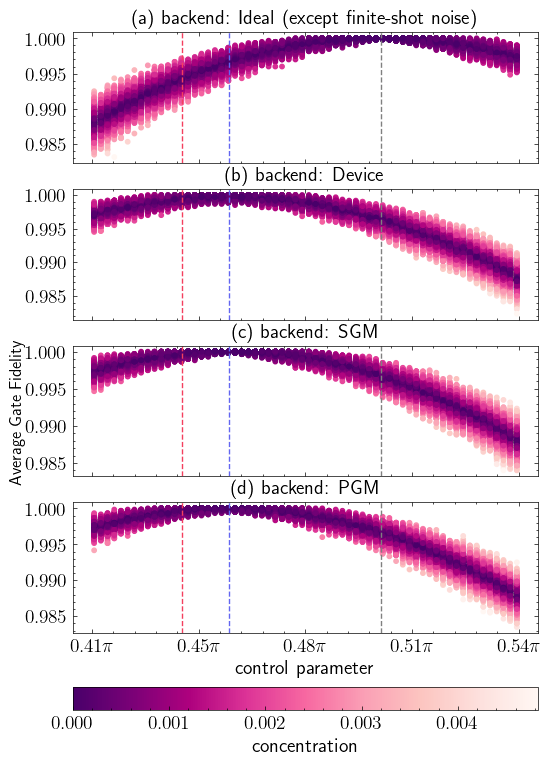

In [49]:
# Get the unique backends to create a subplot for each
backends = [
    "Noiseless",
    "Device",
    "SGM",
    "PGM",
]
n_backends = len(backends)

with plt.style.context("science"):
    # Create a figure and a set of subplots stacked vertically
    # The size is adjusted based on the number of backends
    fontsize = 14
    fig, axes = plt.subplots(
        n_backends,
        1,
        figsize=(6, n_backends * 2.5),
        sharex=True,  # Share the x-axis across all subplots
        # squeeze=False,  # Ensures `axes` is always a 2D array
    )
    axes = sq.visualization.assert_list_of_axes(axes)

    # Create a placeholder for the scatter plot object for the colorbar
    scatter = None

    # Iterate over each backend and its corresponding subplot axis
    for i, backend in enumerate(backends):
        ax = axes[i]

        # Filter the DataFrame for the current backend
        backend_df = agfs_df[agfs_df["backend"] == backend]

        # Create the scatter plot on the specific axis
        # This is equivalent to geom_point() + aes(...)
        scatter = ax.scatter(
            x=backend_df["param"],
            y=backend_df["AGF"],
            c=backend_df["concentration"],
            cmap="RdPu_r",  # Equivalent to scale_color_continuous(cmap_name="viridis")
            s=10.0,
            rasterized=True,
        )

        ax.axvline(
            optimized_results["PGM"].item(), linestyle="dashed", color=palette["PGM"]
        )
        ax.axvline(
            optimized_results["SGM"].item(), linestyle="dashed", color=palette["SGM"]
        )
        ax.axvline(float(jnp.pi / 2), linestyle="dashed", color="gray")

        # Set the y-axis label and a title that mimics the facet label
        # ax.set_ylabel("AGF")
        backname_display_name = backend if backend != "Noiseless" else "Ideal (except finite-shot noise)"
        ax.set_title(f"({chr(ord('a') + i)}) backend: {backname_display_name}", loc="center")

    # Add a label to the shared x-axis on the bottom-most plot
    axes[-1].set_xlabel(r"control parameter")
    format_x_axis_as_pi_specific(axes[-1])

    fig.supylabel("Average Gate Fidelity")

    assert scatter is not None
    # --- MODIFIED SECTION ---
    # Add a single horizontal colorbar at the bottom of the figure
    cbar = fig.colorbar(
        scatter,
        ax=axes,  # Associate the colorbar with all subplots
        label="concentration",
        orientation="horizontal",  # Set orientation to horizontal
        location="bottom",  # Place the colorbar at the bottom
        pad=0.07,  # Increase padding to prevent overlap with x-axis label
    )
    # cbar.ax.tick_params(labelsize=fontsize)
    sq.visualization.set_fontsize(cbar.ax, fontsize)
    for ax in axes:
        sq.visualization.set_fontsize(ax, fontsize)

fig.savefig("fig_control_sweep_avg_gate_fidelity.pdf", bbox_inches="tight")
fig

In [43]:
_pgm_jsds = []
_sgm_jsds = []
for ctrl_idx, ctrl_param in enumerate(control_parameters):
    reference_agfs_sample = jnp.array(
        agfs_df.query("param_idx == @ctrl_idx & backend == 'Device'")["AGF"].to_numpy()
    )
    pgm_agfs_sample = jnp.array(
        agfs_df.query("param_idx == @ctrl_idx & backend == 'PGM'")["AGF"].to_numpy()
    )
    sgm_agfs_sample = jnp.array(
        agfs_df.query("param_idx == @ctrl_idx & backend == 'SGM'")["AGF"].to_numpy()
    )

    pgm_jsd = sq.probabilistic.jensenshannon_divergence_from_sample(
        reference_agfs_sample, pgm_agfs_sample
    )
    sgm_jsd = sq.probabilistic.jensenshannon_divergence_from_sample(
        reference_agfs_sample, sgm_agfs_sample
    )

    _pgm_jsds.append(pgm_jsd)
    _sgm_jsds.append(sgm_jsd)

pgm_jsds = jnp.array(_pgm_jsds)
sgm_jsds = jnp.array(_sgm_jsds)

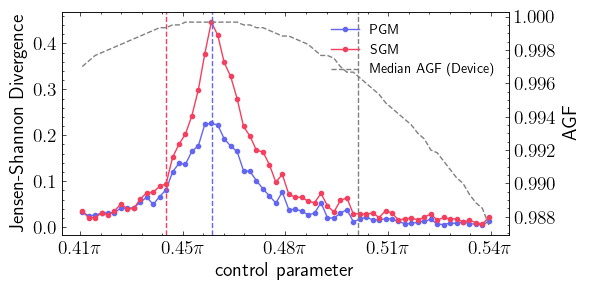

In [51]:
with plt.style.context("science"):
    fig, ax = plt.subplots(figsize=(6, 3))

    ax.plot(control_parameters, pgm_jsds, ".-", label="PGM", color=palette["PGM"])
    ax.plot(control_parameters, sgm_jsds, ".-", label="SGM", color=palette["SGM"])

    ax.set_xlabel(r"control parameter")
    ax.set_ylabel("Jensen-Shannon Divergence")
    # ax.axhline(y=0.0, linestyle="dashed", color="black", label="ideal JSD value")

    ax.axvline(
        optimized_results["PGM"].item(), linestyle="dashed", color=palette["PGM"]
    )
    ax.axvline(
        optimized_results["SGM"].item(), linestyle="dashed", color=palette["SGM"]
    )
    ax.axvline(float(jnp.pi / 2), linestyle="dashed", color="gray")

    twin_ax = ax.twinx()
    median_true_agfs = (
        agfs_df[agfs_df["backend"] == "Device"]
        .groupby("param")["AGF"]
        .median()
        .to_numpy()
    )
    twin_ax.plot(
        control_parameters,
        median_true_agfs,
        "--",
        color="gray",
        label="Median AGF (Device)",
    )

    # expected_sgm_agfs = (
    #     agfs_df[agfs_df["backend"] == "SGM"]
    #     .groupby("param")["AGF"]
    #     .mean()
    #     .to_numpy()
    # )
    # twin_ax.plot(
    #     control_parameters,
    #     expected_sgm_agfs,
    #     "--",
    #     color=palette['SGM'],
    #     label="Expected AGF (SGM)",
    # )

    twin_ax.set_ylabel("AGF")

    # --- Unified Legend ---
    # Collect lines and labels from both axes
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = twin_ax.get_legend_handles_labels()
    format_x_axis_as_pi_specific(ax)

    for item in (
        [twin_ax.title, twin_ax.xaxis.label, twin_ax.yaxis.label]
        + twin_ax.get_xticklabels()
        + twin_ax.get_yticklabels()
    ):
        item.set_fontsize(fontsize)

    # Create a single legend for all lines
    sq.visualization.set_fontsize(ax, fontsize)
    ax.legend(lines + lines2, labels + labels2, loc="upper right")

    # ax.legend()
fig.tight_layout()
fig.savefig("fig_jsd_average_gate_fidelity.pdf")
fig

In [22]:
CHANGE_ME_N_UNITARY = 1000

In [23]:
key = jax.random.key(0)
key, subkey = jax.random.split(key)

results = {}

for params_optimized_by, params in optimized_results.items():
    results[params_optimized_by] = {
        "param": optimized_results[params_optimized_by],
        "backend": {},
    }

    # backend: True
    key, unitaries_key = jax.random.split(key, 2)
    # This is an expensive computation.
    interm_unitaries = ml.make_prepare_unitary_ensemble(
        ml.make_final_returned_whitebox_fn(data_model.solver), CHANGE_ME_N_UNITARY
    )(unitaries_key, params)

    true_optimized_expvals = jnp.zeros(shape=(NUM_REALIZATIONS, 18))

    for exp_idx, exp in enumerate(sq.constant.default_expectation_values_order):

        intermediate_expval = sq.physics.calculate_exp(
            interm_unitaries,
            operator=exp.observable_matrix,
            density_matrix=exp.initial_density_matrix,
        )
        probs = sq.utils.expectation_value_to_prob_plus(intermediate_expval)

        key, subkey = jax.random.split(key)
        sim = jax.vmap(ml.simulate_the_shot, in_axes=(0, None))(
            jax.random.split(subkey, int(NUM_REALIZATIONS * shots)), probs
        )

        expval_sample = sim.reshape(NUM_REALIZATIONS, shots).mean(1)
        true_optimized_expvals = true_optimized_expvals.at[..., exp_idx].set(
            expval_sample
        )

    results[params_optimized_by]["backend"]["Device"] = {
        "expectation_values": true_optimized_expvals,
        "AGF_distribution": jax.vmap(sx_agf_fn)(true_optimized_expvals),
    }

    # Prepare for PGM and SGM
    unitary = loaded_data.whitebox(params)[-1, :, :]
    key, subkey = jax.random.split(key)

    # backend: PGM
    pgm_samples = jnp.mean(
        sq.utils.binary_to_eigenvalue(
            jax.vmap(pgm_predictive_fn, in_axes=(0, None, None))(
                jax.random.split(subkey, NUM_REALIZATIONS),
                ml.feature_map(params),
                unitary,
            )["obs"]
        ),
        axis=1,
    )

    results[params_optimized_by]["backend"]["PGM"] = {
        "expectation_values": pgm_samples,
        "AGF_distribution": jax.vmap(sx_agf_fn)(pgm_samples),
    }

    # Predictior: SGM
    key, subkey = jax.random.split(key)

    sgm_samples = jax.vmap(sgm_predictive_model, in_axes=(0, None, None))(
        jax.random.split(subkey, NUM_REALIZATIONS),
        ml.feature_map(params),
        unitary,
    )

    results[params_optimized_by]["backend"]["SGM"] = {
        "expectation_values": sgm_samples,
        "AGF_distribution": jax.vmap(sx_agf_fn)(sgm_samples),
    }


In [24]:
sq.data.save_pytree_to_json(results, pathlib.Path("./data/PSD/0001/optimized_analysis_N1000.json"))

In [25]:

results = sq.data.load_pytree_from_json(pathlib.Path("./data/PSD/0001/optimized_analysis_N1000.json"))

In [26]:
jsd_raws = []

for params_optimized_by, params in optimized_results.items():
    reference_expvals_sample = results[params_optimized_by]["backend"]["Device"][
        "expectation_values"
    ]
    pgm_expvals_sample = results[params_optimized_by]["backend"]["PGM"][
        "expectation_values"
    ]
    sgm_expvals_sample = results[params_optimized_by]["backend"]["SGM"][
        "expectation_values"
    ]

    pgm_expvals_jsd = jax.vmap(
        sq.probabilistic.jensenshannon_divergence_from_sample, in_axes=(1, 1)
    )(reference_expvals_sample, pgm_expvals_sample)
    sgm_expvals_jsd = jax.vmap(
        sq.probabilistic.jensenshannon_divergence_from_sample, in_axes=(1, 1)
    )(reference_expvals_sample, sgm_expvals_sample)

    for exp_idx, exp in enumerate(sq.constant.default_expectation_values_order):
        name = rf"$\langle {exp.observable} \rangle_" + "{" + rf"|{exp.initial_state}\rangle" + "}$"
        jsd_raws.append(
            {
                "Expectation Value": name,
                "backend": "SGM",
                "JSD": sgm_expvals_jsd[exp_idx].item(),
                "predictor": params_optimized_by,
            }
        )

        jsd_raws.append(
            {
                "Expectation Value": name,
                "backend": "PGM",
                "JSD": pgm_expvals_jsd[exp_idx].item(),
                "predictor": params_optimized_by,
            }
        )

jsd_df = pd.DataFrame(jsd_raws)
jsd_df

,Expectation Value,backend,JSD,predictor
0,$\langle X \rangle_{|+\rangle}$,SGM,0.072810,SGM
1,$\langle X \rangle_{|+\rangle}$,PGM,0.015713,SGM
2,$\langle X \rangle_{|-\rangle}$,SGM,0.077607,SGM
3,$\langle X \rangle_{|-\rangle}$,PGM,0.015262,SGM
4,$\langle X \rangle_{|r\rangle}$,SGM,0.007110,SGM
...,...,...,...,...
67,$\langle Z \rangle_{|l\rangle}$,PGM,0.066273,PGM
68,$\langle Z \rangle_{|0\rangle}$,SGM,0.006557,PGM
69,$\langle Z \rangle_{|0\rangle}$,PGM,0.004021,PGM
70,$\langle Z \rangle_{|1\rangle}$,SGM,0.011403,PGM


In [27]:
def plot_stat(params_optimized_by: str):
    fontsize = 16
    with plt.style.context("science"):

        fig, axes = plt.subplots(2, 1, figsize=(8, 4))
        axes = sq.visualization.assert_list_of_axes(axes)

        s = sns.histplot(
            {
                "Device": results[params_optimized_by]["backend"]["Device"]["AGF_distribution"],
                "PGM": results[params_optimized_by]["backend"]["PGM"]["AGF_distribution"],
                "SGM": results[params_optimized_by]["backend"]["SGM"]["AGF_distribution"],
            },
            ax=axes[0],
            multiple="dodge",
            palette=palette,
            shrink=1.2 if params_optimized_by == "SGM" else 2.5,
        )

        axes[0].set_ylabel("Histogram of AGF")
        axes[0].set_xlabel("Average Gate Fidelity")
        axes[0].set_yscale("log")
        # axes[0].legend(handles, labels)
        # print(labels, )

        sns.barplot(
            jsd_df.query("predictor == @params_optimized_by"),
            x="Expectation Value",
            y="JSD",
            ax=axes[1],
            hue="backend",
            palette=palette,
        )
        axes[1].set_ylabel("JSD")
        axes[1].legend()

        ax = axes[0]
        for item in (
            [ax.title, ax.xaxis.label, ax.yaxis.label]
            + ax.get_xticklabels()
            + ax.get_yticklabels()
        ):
            item.set_fontsize(fontsize)

        plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

        # sq.visualization.set_fontsize(axes[0], fontsize)
        sq.visualization.set_fontsize(axes[1], fontsize)
        axes[1].legend(loc="upper right", fontsize=fontsize, frameon=True, ncols=2)
        fig.suptitle(f"Parameters optimized using {params_optimized_by}", fontsize=fontsize)
        fig.tight_layout()

    fig.savefig(f"fig_optimized_by_{params_optimized_by}_stat.pdf")
    plt.close()
    return fig

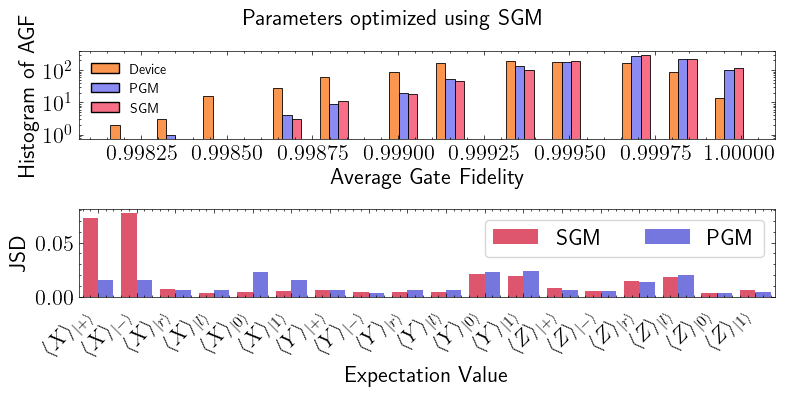

In [28]:
plot_stat("SGM")

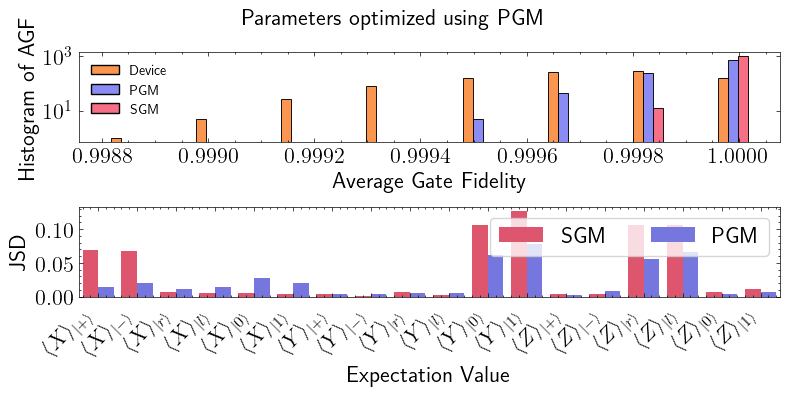

In [29]:
plot_stat("PGM")

## Calculate statistics of AGF

In [30]:
def generate_latex_table(optimized_results, results):
    """Generate LaTeX table for control calibration statistics."""
    
    # Start the LaTeX table
    latex_code = []
    latex_code.append(r"\begin{table}[htb]")
    latex_code.append(r"    \renewcommand{\arraystretch}{1.3}")
    latex_code.append(r"    \centering")
    latex_code.append(r"    \begin{tabular}{llr}")
    latex_code.append(r"        \hline\hline")
    latex_code.append(r"        \textbf{Control} & \textbf{Parameter} & \textbf{Value} \\")
    latex_code.append(r"        \hline")
    
    # Process each control method
    for i, (params_optimized_by, params) in enumerate(optimized_results.items()):
        # Get the data
        reference_agf_samples = results[params_optimized_by]["backend"]["Device"]["AGF_distribution"]
        pgm_agf_samples = results[params_optimized_by]["backend"]["PGM"]["AGF_distribution"]
        sgm_agf_samples = results[params_optimized_by]["backend"]["SGM"]["AGF_distribution"]
        
        pgm_agf_jsd = sq.probabilistic.jensenshannon_divergence_from_sample(
            reference_agf_samples, pgm_agf_samples
        )
        sgm_agf_jsd = sq.probabilistic.jensenshannon_divergence_from_sample(
            reference_agf_samples, sgm_agf_samples
        )
        
        # Calculate values
        param_value = params.item()
        agf_true = reference_agf_samples.mean().item()
        agf_sgm = sgm_agf_samples.mean().item()
        agf_pgm = pgm_agf_samples.mean().item()
        jsd_sgm = sgm_agf_jsd.item()
        jsd_pgm = pgm_agf_jsd.item()
        ratio = sgm_agf_jsd / pgm_agf_jsd
        
        # Format the control name
        control_name = params_optimized_by.upper()
        
        # Add multirow for the control name
        latex_code.append(f"        \\multirow{{7}}{{*}}{{\\acrshort{{{control_name.lower()}}}}}")
        latex_code.append(f"                         & $\\theta^{{*}}$ & {param_value:.6f} \\\\")
        latex_code.append(f"                         & $\\mathbb{{E}}[\\mathrm{{AGF}}]$ by True & {agf_true:.7f} \\\\")
        latex_code.append(f"                         & $\\mathbb{{E}}[\\mathrm{{AGF}}]$ by SGM & {agf_sgm:.7f} \\\\")
        latex_code.append(f"                         & $\\mathbb{{E}}[\\mathrm{{AGF}}]$ by PGM & {agf_pgm:.7f} \\\\")
        latex_code.append(f"                         & $D_{{\\rm JSD}}(\\mathrm{{SGM}}|\\mathrm{{True}})$ & {jsd_sgm:.4f} \\\\")
        latex_code.append(f"                         & $D_{{\\rm JSD}}(\\mathrm{{PGM}}|\\mathrm{{True}})$ & {jsd_pgm:.4f} \\\\")
        latex_code.append(f"                         & Ratio & \\textbf{{{ratio:.4f}}} \\\\")
        latex_code.append(r"        \hline")
    
    # Close the table
    latex_code.append(r"        \hline")
    latex_code.append(r"    \end{tabular}")
    latex_code.append(r"    \caption{Statistic relevant to the control calibration experiments}")
    latex_code.append(r"    \label{tab:control-calibration-stat}")
    latex_code.append(r"\end{table}")
    
    return "\n".join(latex_code)

# Usage - replace your existing loop with this:
latex_table = generate_latex_table(optimized_results, results)
print(latex_table)

# If you want to save to file:
# with open('control_calibration_table.tex', 'w') as f:
#     f.write(latex_table)


\begin{table}[htb]
    \renewcommand{\arraystretch}{1.3}
    \centering
    \begin{tabular}{llr}
        \hline\hline
        \textbf{Control} & \textbf{Parameter} & \textbf{Value} \\
        \hline
        \multirow{7}{*}{\acrshort{sgm}}
                         & $\theta^{*}$ & 1.384006 \\
                         & $\mathbb{E}[\mathrm{AGF}]$ by True & 0.9993480 \\
                         & $\mathbb{E}[\mathrm{AGF}]$ by SGM & 0.9996295 \\
                         & $\mathbb{E}[\mathrm{AGF}]$ by PGM & 0.9996110 \\
                         & $D_{\rm JSD}(\mathrm{SGM}|\mathrm{True})$ & 0.1064 \\
                         & $D_{\rm JSD}(\mathrm{PGM}|\mathrm{True})$ & 0.0920 \\
                         & Ratio & \textbf{1.1568} \\
        \hline
        \multirow{7}{*}{\acrshort{pgm}}
                         & $\theta^{*}$ & 1.428679 \\
                         & $\mathbb{E}[\mathrm{AGF}]$ by True & 0.9996952 \\
                         & $\mathbb{E}[\mathrm{AGF}]$ by SGM & 0.9999978 \\


In [31]:
# # At the optimzied parameters

# for params_optimized_by, params in optimized_results.items():
#     print(f"{'='*40}")
#     print(params_optimized_by)
#     reference_agf_samples = results[params_optimized_by]["backend"]["Device"][
#         "AGF_distribution"
#     ]
#     pgm_agf_samples = results[params_optimized_by]["backend"]["PGM"]["AGF_distribution"]
#     sgm_agf_samples = results[params_optimized_by]["backend"]["SGM"]["AGF_distribution"]

#     pgm_agf_jsd = sq.probabilistic.jensenshannon_divergence_from_sample(
#         reference_agf_samples, pgm_agf_samples
#     )
#     sgm_agf_jsd = sq.probabilistic.jensenshannon_divergence_from_sample(
#         reference_agf_samples, sgm_agf_samples
#     )

#     print(f"{'parameter ':<15} {params.item()}")
#     print(f"{'AGF by True:':<15} {reference_agf_samples.mean().item()}")
#     print(f"{'AGF by SGM:':<15} {sgm_agf_samples.mean().item()}")
#     print(f"{'AGF by PGM:':<15} {pgm_agf_samples.mean().item()}")
#     print(f"{'JSD(SGM|True):':<15} {sgm_agf_jsd.item()}")
#     print(f"{'JSD(PGM|True):':<15} {pgm_agf_jsd.item()}")
#     print(f"{'Ratio:':<15} {sgm_agf_jsd / pgm_agf_jsd}")

## Parameters

In [32]:
from flax import linen as nn
import typing


def model_summary(
    model: nn.Module,
    pulse_sequence: sq.control.ControlSequence,
    params_transform_fn: list[typing.Callable] = [],
):
    sample_params = pulse_sequence.sample_params(jax.random.key(0))

    array = sq.control.list_of_params_to_array(
        sample_params, pulse_sequence.get_parameter_names()
    )

    params = jnp.broadcast_to(
        array,
        (1,) + array.shape,
    )

    for fn in params_transform_fn:
        params = fn(params)

    # trainable parameters count
    return model.tabulate(
        jax.random.key(0),
        params,
    )


print(
    model_summary(
        sq.models.linen.WoModel(**sgm_model_state.config),
        loaded_data.control_sequence,
        [ml.feature_map],
    )
)


                                WoModel Summary                                 
┏━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module  ┃ inputs       ┃ outputs             ┃ params              ┃
┡━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│         │ WoModel │ float64[1,4] │ X:                  │                     │
│         │         │              │ complex128[1,2,2]   │                     │
│         │         │              │ Y:                  │                     │
│         │         │              │ complex128[1,2,2]   │                     │
│         │         │              │ Z:                  │                     │
│         │         │              │ complex128[1,2,2]   │                     │
├─────────┼─────────┼──────────────┼─────────────────────┼─────────────────────┤
│ Dense_0 │ Dense   │ float64[1,4] │ float64[1,5]        │ bias: float32[5]    │
│         │         │      

In [33]:
def generate_latex_table(data, caption="", label="", arraystretch=1.3):
    """
    Generate a LaTeX table from structured data.

    Parameters:
    - data: List of dictionaries, each representing a category
    - caption: Table caption
    - label: Table label for referencing
    - arraystretch: Row spacing multiplier

    Expected data structure:
    [
        {
            'category': 'Category Name',
            'items': [
                {'parameter': 'Param Name', 'value': 'Value'},
                {'parameter': 'Param Name', 'value': 'Value', 'multiline': True},
                {'subcategory': 'Subcat Name'},  # For subcategory headers
                {'parameter': 'Param Name', 'value': 'Value'},
            ]
        },
        ...
    ]
    """

    latex_lines = []

    # Table header
    latex_lines.append("\\begin{table}[htb]")
    latex_lines.append(f"    \\renewcommand{{\\arraystretch}}{{{arraystretch}}}")
    latex_lines.append("    \\centering")
    latex_lines.append("    % Using \\makecell for specific line breaks")
    latex_lines.append("    \\begin{tabular}{llr}")
    latex_lines.append("        \\hline\\hline")
    latex_lines.append(
        "        \\textbf{Category}               & \\textbf{Parameter}            & \\textbf{Value}         \\\\"
    )
    latex_lines.append("        \\hline")

    # Process each category
    for category_data in data:
        category_name = category_data["category"]
        items = category_data["items"]

        # Count total rows for this category (excluding subcategory headers)
        total_rows = sum(1 for item in items if "subcategory" not in item)

        # Process items
        first_row = True
        for i, item in enumerate(items):
            if "subcategory" in item:
                # Subcategory header
                line = f"                                        & \\textbf{{{item['subcategory']}}}     &                        \\\\"
            else:
                # Regular parameter row
                param = item["parameter"]
                value = str(item["value"])

                # Handle multiline parameters
                if item.get("multiline", False):
                    param = f"\\makecell[l]{{{param}}}"

                if first_row:
                    # First row with category multirow
                    if category_data.get("multiline_category", False):
                        category_display = f"\\makecell[l]{{{category_name}}}"
                    else:
                        category_display = category_name

                    line = f"        \\multirow{{{total_rows}}}{{*}}{{{category_display}}} & {param} & {value}                    \\\\"
                    first_row = False
                else:
                    # Subsequent rows
                    line = f"                                        & {param} & {value} \\\\"

            latex_lines.append(line)

        latex_lines.append("        \\hline")

    # Table footer
    latex_lines.append("        \\hline")
    latex_lines.append("    \\end{tabular}")
    if caption:
        latex_lines.append(f"    \\caption{{{caption}}}")
    if label:
        latex_lines.append(f"    \\label{{{label}}}")
    latex_lines.append("\\end{table}")

    return "\n".join(latex_lines)


config = loaded_data.experiment_data.experiment_config

qubit = config.qubits[0]
shots = config.shots
sample_size = config.sample_size

noise_config = config.additional_info
DETUNE = float(noise_config["DETUNE"])
NOISE_STR = float(noise_config["NOISE_STR"])
TROTTERIZATION = bool(noise_config["TROTTERIZATION"])
TROTTER_STEPS = int(noise_config["TROTTER_STEPS"])

training_size = 900
testing_size = 100


def get_optimizer_options(num_epochs: int):
    return {
        "name": "adamw",
        "scheduler": "Cosine decay with warmup",
        "init_value": 1e-6,
        "peak_value": 1e-2,
        "warmup_steps": num_epochs * 0.1,
        "decay_steps": num_epochs,
        "end_value": 1e-6,
    }


# SGM
sgm_model_config = sq.model.ModelData.from_file(sgm_model_path / "model.json").config
num_epochs = 1000
sgm_optimizer = get_optimizer_options(8 * num_epochs)
sgm_optimizer["num_epochs"] = num_epochs
num_trainable_parameters = 205

## Control SGM
max_iter = 1000
sgm_control_optimizer = get_optimizer_options(max_iter)
sgm_control_optimizer["num_iteration"] = max_iter

# PGM
pgm_model_config = sq.probabilistic.SVIResult.from_file(
    PGM_model_path / "model.json"
).config
num_epochs = 10_000
pgm_optimizer = get_optimizer_options(num_epochs)
pgm_optimizer["num_epochs"] = num_epochs
num_variational_parameters = num_trainable_parameters * 2

## Control PGM
max_iter = 1500
pgm_control_optimizer = get_optimizer_options(8000)
pgm_control_optimizer["num_iteration"] = max_iter

# Example usage with your table structure:

data = [
    {
        "category": "Quantum System",
        "items": [
            {
                "parameter": "Qubit Frequency $\\omega_{q}$",
                "value": config.qubits[0].frequency,
            },
            {
                "parameter": "Qubit Drive Strength $\\Omega$",
                "value": config.qubits[0].drive_strength,
            },
            {"parameter": "Shots per Sample $n$", "value": config.shots},
        ],
    },
    {
        "category": "Noise\\\\Configuration",
        "multiline_category": True,
        "items": [
            {"parameter": "Detuning \\(\\Delta\\)", "value": DETUNE},
            {
                "parameter": "Stochastic Noise \\\\ Strength \\(\\delta\\)",
                "value": NOISE_STR,
                "multiline": True,
            },
            {"parameter": "Trotter Steps", "value": TROTTER_STEPS},
        ],
    },
    {
        "category": "Dataset",
        "items": [
            {"parameter": "Sample Size", "value": config.sample_size},
            {"parameter": "Training Size", "value": int(0.9 * config.sample_size)},
            {"parameter": "Testing Size", "value": int(0.1 * config.sample_size)},
        ],
    },
    {
        "category": "Optimizer \\\\ Shared Config",
        "multiline_category": True,
        "items": [
            {"parameter": "Algorithm", "value": "adamw"},
            {
                "parameter": "Scheduler",
                "value": "\\makecell{Cosine decay \\\\ with warmup}",
            },
            {"parameter": "Initial Learning Rate", "value": "$10^{-6}$"},
            {"parameter": "Peak Learning Rate", "value": "0.01"},
            {"parameter": "End Learning Rate", "value": "$10^{-6}$"},
        ],
    },
    {
        "category": "\\acrshort{sgm}",
        "items": [
            {"subcategory": "Characterization"},
            {"parameter": "\\#Epoch", "value": "1,000"},
            {"parameter": "Optimizer warm-up step", "value": "800"},
            {"parameter": "Optimizer decay step", "value": "8,000"},
            {"parameter": "\\#Parameters", "value": "205 (trainable)"},
            {"parameter": "Wall Clock (s)", "value": rf"$\sim${times['SGM']['training']:.0f}"},
            {"subcategory": "Control"},
            {"parameter": "Iterations", "value": "1,000"},
            {"parameter": "Optimizer warm-up step", "value": "100"},
            {"parameter": "Optimizer decay step", "value": "1,000"},
            {"parameter": "Wall Clock (s)", "value": rf"$\sim${times['SGM']['control']:.0f}"},
        ],
    },
    {
        "category": "\\acrshort{pgm}",
        "items": [
            {"subcategory": "Characterization"},
            {"parameter": "\\#Epoch", "value": "10,000"},
            {"parameter": "Optimizer warm-up step", "value": "1,000"},
            {"parameter": "Optimizer decay step", "value": "10,000"},
            {"parameter": "\\#Parameters", "value": "410 (trainable)"},
            {"parameter": "Wall Clock (s)", "value": rf"$\sim${times['PGM']['training']:.0f}"},
            {"subcategory": "Control"},
            {"parameter": "Iterations", "value": "1,500"},
            {"parameter": "Optimizer warm-up step", "value": "800"},
            {"parameter": "Optimizer decay step", "value": "8,000"},
            {"parameter": "Wall Clock (s)", "value": rf"$\sim${times['PGM']['control']:.0f}"},
        ],
    },
]


# Generate the table
latex_code = generate_latex_table(
    data,
    caption="Detailed System, Dataset, and Optimizer Parameters",
    label="tab:detailed-hyperparams",
)
print(latex_code)


\begin{table}[htb]
    \renewcommand{\arraystretch}{1.3}
    \centering
    % Using \makecell for specific line breaks
    \begin{tabular}{llr}
        \hline\hline
        \textbf{Category}               & \textbf{Parameter}            & \textbf{Value}         \\
        \hline
        \multirow{3}{*}{Quantum System} & Qubit Frequency $\omega_{q}$ & 5.0                    \\
                                        & Qubit Drive Strength $\Omega$ & 0.1 \\
                                        & Shots per Sample $n$ & 1000 \\
        \hline
        \multirow{3}{*}{\makecell[l]{Noise\\Configuration}} & Detuning \(\Delta\) & 0.001                    \\
                                        & \makecell[l]{Stochastic Noise \\ Strength \(\delta\)} & 0.01 \\
                                        & Trotter Steps & 10000 \\
        \hline
        \multirow{3}{*}{Dataset} & Sample Size & 1000                    \\
                                        & Training Size & 900 \\
           

In [34]:
sgm_optimizer, sgm_control_optimizer, pgm_optimizer, pgm_control_optimizer

({'name': 'adamw',
  'scheduler': 'Cosine decay with warmup',
  'init_value': 1e-06,
  'peak_value': 0.01,
  'warmup_steps': 800.0,
  'decay_steps': 8000,
  'end_value': 1e-06,
  'num_epochs': 1000},
 {'name': 'adamw',
  'scheduler': 'Cosine decay with warmup',
  'init_value': 1e-06,
  'peak_value': 0.01,
  'warmup_steps': 100.0,
  'decay_steps': 1000,
  'end_value': 1e-06,
  'num_iteration': 1000},
 {'name': 'adamw',
  'scheduler': 'Cosine decay with warmup',
  'init_value': 1e-06,
  'peak_value': 0.01,
  'warmup_steps': 1000.0,
  'decay_steps': 10000,
  'end_value': 1e-06,
  'num_epochs': 10000},
 {'name': 'adamw',
  'scheduler': 'Cosine decay with warmup',
  'init_value': 1e-06,
  'peak_value': 0.01,
  'warmup_steps': 800.0,
  'decay_steps': 8000,
  'end_value': 1e-06,
  'num_iteration': 1500})